# Processed Sensor Readings (Filtered & Smoothed)

Plots the **processed** readings for a single session, loaded from the `processed/` folder.
These have already passed through the cleaning pipeline (zero-interpolation, artifact patching,
Savitzky-Golay smoothing, and baseline/drift correction for MEMS) — see `mems_filter.ipynb`.

Both sensor types are shown: **MEMS** (VOC, NH3, HCHO, in volts) and **SPEC**
(H2S, EtOH, in ppm). The MEMS (`mems_*.pkl`) and SPEC (`spec_*.pkl`) files are merged on
`elapsed_s`. Change `SESSION` to view a different run.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED_DIR = "processed"
SESSION = "blood_4"   # any session with mems_<SESSION>.pkl + spec_<SESSION>.pkl

# (column, axis label with units)
CHANNELS = [
    ("voc",      "VOC (V)"),
    ("nh3",      "NH3 (V)"),
    ("hcho",     "HCHO (V)"),
    ("h2s_ppm",  "H2S (ppm)"),
    ("etoh_ppm", "EtOH (ppm)"),
]

In [3]:
def load_processed(session):
    mems = pd.read_pickle(f"{PROCESSED_DIR}/mems_{session}.pkl")
    spec = pd.read_pickle(f"{PROCESSED_DIR}/spec_{session}.pkl")
    # merge MEMS + SPEC on the shared elapsed_s timeline
    df = pd.merge(mems[["elapsed_s", "voc", "nh3", "hcho"]],
                  spec[["elapsed_s", "h2s_ppm", "etoh_ppm"]],
                  on="elapsed_s", how="inner")
    df["elapsed_min"] = df["elapsed_s"] / 60.0
    return df

proc = load_processed(SESSION)
print(f"{SESSION}: {len(proc)} samples, {proc['elapsed_min'].iloc[-1]:.1f} min total")
proc[[c for c, _ in CHANNELS]].describe().round(4)

blood_4: 2357 samples, 41.2 min total


,voc,nh3,hcho,h2s_ppm,etoh_ppm
count,2357.0000,2357.0000,2357.0000,2357.0000,2357.0000
mean,0.0103,0.1480,0.1435,0.0801,1.3131
std,0.0120,0.1808,0.1598,0.1002,1.3430
min,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0002,0.0002,0.0000,0.1775
50%,0.0000,0.0049,0.0043,0.0000,0.3988
75%,0.0219,0.3268,0.3132,0.1863,3.0076
max,0.0331,0.4675,0.3790,0.2641,3.4360


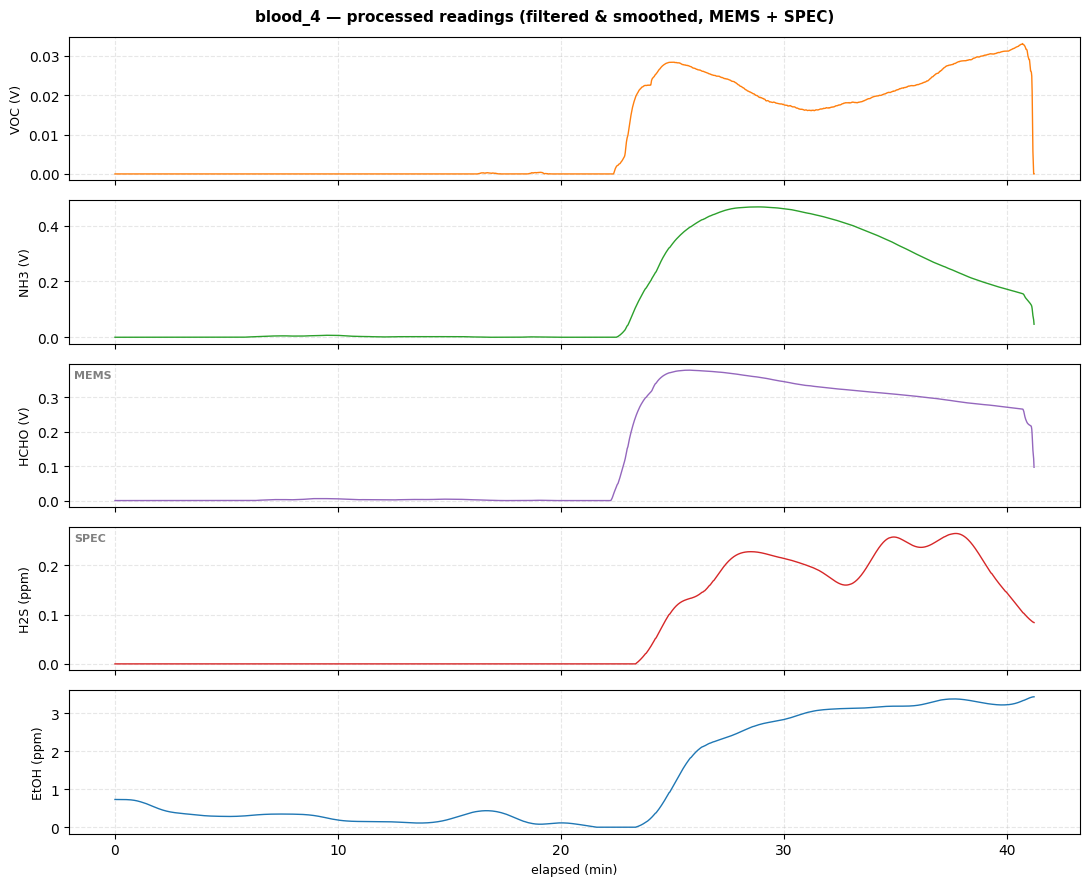

In [ ]:
fig, axes = plt.subplots(len(CHANNELS), 1, figsize=(11, 9), sharex=True)
fig.suptitle(f"{SESSION} — processed readings (filtered & smoothed, MEMS + SPEC)",
             fontsize=11, fontweight="bold")

COLORS = {"voc":"tab:orange", "nh3":"tab:green", "hcho":"tab:purple",
          "h2s_ppm":"tab:red", "etoh_ppm":"tab:blue"}

for ax, (col, ylabel) in zip(axes, CHANNELS):
    ax.plot(proc["elapsed_min"], proc[col], color=COLORS[col], linewidth=1.0)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, alpha=0.3, linestyle="--")

# visual divider between MEMS (top 3) and SPEC (bottom 2)
axes[2].annotate("MEMS", xy=(0.005, 0.9), xycoords="axes fraction",
                 fontsize=8, color="grey", fontweight="bold")
axes[3].annotate("SPEC", xy=(0.005, 0.9), xycoords="axes fraction",
                 fontsize=8, color="grey", fontweight="bold")

axes[-1].set_xlabel("elapsed (min)", fontsize=9)
plt.tight_layout()
plt.show()